In [298]:
pip install numpy pandas scikit-learn matplotlib


[notice] A new release of pip available: 22.2.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [299]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

from sklearn.linear_model import RidgeClassifier

In [300]:
columns = [
    "variance",
    "skewness",
    "curtosis",
    "entropy",
    "class",
]

df = pd.read_csv(
    "data_banknote_authentication.txt",
    header=None,
    names=columns,
)

df.head()

,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [301]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   variance  1372 non-null   float64
 1   skewness  1372 non-null   float64
 2   curtosis  1372 non-null   float64
 3   entropy   1372 non-null   float64
 4   class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


In [302]:
df.describe()

,variance,skewness,curtosis,entropy,class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


In [303]:
print("Размер датасета:", df.shape)

print("\nПропуски:")
print(df.isna().sum())

print("\nРаспределение классов:")
print(df["class"].value_counts())

Размер датасета: (1372, 5)

Пропуски:
variance    0
skewness    0
curtosis    0
entropy     0
class       0
dtype: int64

Распределение классов:
class
0    762
1    610
Name: count, dtype: int64


In [304]:
X = df.drop(columns="class").to_numpy(dtype=float)

y = df["class"].replace({
    0: -1,
    1: 1,
}).to_numpy(dtype=float)

print("X:", X.shape)
print("y:", y.shape)

print("Классы:", np.unique(y))

X: (1372, 4)
y: (1372,)
Классы: [-1.  1.]


In [305]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (1097, 4)
Test: (275, 4)


In [306]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [307]:
print("Средние:")
print(X_train_scaled.mean(axis=0))

print("\nСтандартные отклонения:")
print(X_train_scaled.std(axis=0))

Средние:
[-8.72390380e-17 -3.24666861e-16 -5.25458336e-16  5.76465848e-16]

Стандартные отклонения:
[1. 1. 1. 1.]


In [ ]:
class LinearClassifier:
    def __init__(
        self,
        learning_rate=0.01,
        beta=0.9,
        l2=0.01,
        alpha=0.01,
        epochs=100,
        random_state=42,
        optimizer="momentum",
        init_method="random",
        sample_order="random",
        bias=0.0,
    ):
        """Задает гиперпараметры, режимы обучения и начальное состояние модели.

        learning_rate — постоянный шаг SGD; beta — коэффициент инерции.
        l2 — коэффициент L2-регуляризации; alpha — коэффициент сглаживания Q.
        epochs — число эпох SGD или предел итераций скорейшего спуска.
        random_state — начальное состояние генератора случайных чисел.
        optimizer — "momentum" или "steepest".
        init_method — "random" или "correlation".
        sample_order — "random" или "margin".
        bias — начальное значение свободного члена.

        w и b хранят параметры модели; v и v_b — накопленные градиенты.
        Q и quality_history хранят рекуррентную оценку качества и ее историю.
        Генератор rng создается при инициализации весов.
        """
        self.learning_rate = learning_rate
        self.beta = beta
        self.l2 = l2
        self.alpha = alpha
        self.epochs = epochs

        self.random_state = random_state
        self.optimizer = optimizer
        self.init_method = init_method
        self.sample_order = sample_order

        self.initial_bias = bias

        self.w = None
        self.b = bias

        self.v = None
        self.v_b = 0.0

        self.Q = None
        self.quality_history = []

        self.rng = None

    def _initialize_weights(self, X, y):
        """Инициализирует веса и генератор случайных чисел перед обучением."""
        n_features = X.shape[1]

        self.rng = np.random.default_rng(self.random_state)

        if self.init_method == "random":
            self.w = self.rng.normal(
                loc=0.0,
                scale=0.01,
                size=n_features,
            )

        elif self.init_method == "correlation":
            self.w = np.array([
                np.corrcoef(X[:, j], y)[0, 1]
                for j in range(n_features)
            ])

            self.w = np.nan_to_num(self.w)

        else:
            raise ValueError(
                f"Unknown init_method: {self.init_method}"
            )

        self.v = np.zeros_like(self.w)
        self.v_b = 0.0

        self.b = self.initial_bias

    def forward(self, X):
        """Вычисляет линейную оценку X @ w + b для объекта или выборки."""
        return X @ self.w + self.b

    def margin(self, X, y):
        """Вычисляет отступы y * f(X).

        Положительный отступ соответствует правильной классификации,
        отрицательный — ошибке, нулевой — границе решения.
        """
        return y * self.forward(X)

    def loss(self, X, y):
        """Возвращает квадратичные потери (f(X) - y) ** 2."""
        prediction = self.forward(X)
        return (prediction - y) ** 2

    def mean_loss(self, X, y, regularized=False):
        """Вычисляет среднюю квадратичную потерю на выборке."""
        risk = np.mean(self.loss(X, y))

        if regularized:
            risk += self.l2 * np.sum(self.w ** 2)

        return float(risk)

    def _get_sample_order(self, X, y):
        """Возвращает индексы объектов в порядке предъявления на текущую эпоху."""
        n_samples = X.shape[0]

        if self.sample_order == "random":
            return self.rng.permutation(n_samples)

        elif self.sample_order == "margin":
            margins = self.margin(X, y)

            return np.argsort(np.abs(margins))

        else:
            raise ValueError(
                f"Unknown sample_order: {self.sample_order}"
            )

    def gradient(self, x, y):
        """Вычисляет градиент квадратичной потери одного объекта без L2-штрафа."""
        prediction = self.forward(x)

        error = prediction - y

        grad_w = 2 * error * x
        grad_b = 2 * error

        return grad_w, grad_b

    def _l2_gradient(self):
        """Вычисляет градиент L2-штрафа по весам: 2 * l2 * w."""
        return 2 * self.l2 * self.w

    def _update_momentum(self, grad_w, grad_b):
        """Обновляет накопленные градиенты весов и смещения с инерцией."""
        self.v = (
            self.beta * self.v
            + grad_w
        )

        self.v_b = (
            self.beta * self.v_b
            + grad_b
        )

        return self.v, self.v_b

    def _update_weights(self, grad_w, grad_b):
        """Выполняет шаг SGD с инерцией для весов и свободного члена."""
        v_w, v_b = self._update_momentum(
            grad_w,
            grad_b,
        )

        self.w -= self.learning_rate * v_w
        self.b -= self.learning_rate * v_b

    def _update_quality(self, current_loss):
        """Обновляет рекуррентную оценку качества и сохраняет ее в истории."""
        if self.Q is None:
            self.Q = float(current_loss)

        else:
            self.Q = (
                (1 - self.alpha) * self.Q
                + self.alpha * current_loss
            )

        self.quality_history.append(self.Q)

        return self.Q

    def _full_gradient(self, X, y):
        """Вычисляет полный градиент регуляризованного риска на всей выборке."""
        predictions = self.forward(X)

        errors = predictions - y

        grad_w = (
            2 * X.T @ errors / len(y)
            + self._l2_gradient()
        )

        grad_b = 2 * np.mean(errors)

        return grad_w, grad_b

    def _find_best_step(
        self,
        X,
        y,
        grad_w,
        grad_b,
    ):
        """Находит шаг, минимизирующий квадратичный риск вдоль антиградиента."""

        residuals = self.forward(X) - y

        projection = X @ grad_w + grad_b

        numerator = (
            np.mean(projection * residuals)
            + self.l2 * np.dot(self.w, grad_w)
        )

        denominator = (
            np.mean(projection ** 2)
            + self.l2 * np.dot(grad_w, grad_w)
        )

        if denominator <= 1e-12:
            return 0.0

        eta = numerator / denominator

        return max(0.0, float(eta))

    def fit(self, X, y):
        """Обучает классификатор.

        В режиме "momentum" каждую эпоху определяет порядок объектов.
        Для каждого объекта вычисляет потерю с L2-штрафом и обновляет Q,
        затем добавляет L2 к градиенту потери и выполняет шаг SGD с инерцией.

        В режиме "steepest" обновляет Q по полному регуляризованному риску,
        вычисляет полный градиент и оптимальный шаг, затем обновляет параметры.
        Обучение завершается при нулевом шаге или достижении предела epochs.
        """
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)

        self._initialize_weights(X, y)

        self.Q = None
        self.quality_history = []

        if self.optimizer == "momentum":

            for epoch in range(self.epochs):

                indices = self._get_sample_order(X, y)

                for idx in indices:
                    x_i = X[idx]
                    y_i = y[idx]

                    current_loss = self.loss(
                        x_i,
                        y_i,
                    ) + self.l2 * np.sum(self.w ** 2)

                    self._update_quality(
                        current_loss
                    )

                    grad_w, grad_b = self.gradient(
                        x_i,
                        y_i,
                    )

                    grad_w += self._l2_gradient()

                    self._update_weights(
                        grad_w,
                        grad_b,
                    )

        elif self.optimizer == "steepest":

            for epoch in range(self.epochs):

                current_loss = self.mean_loss(
                    X,
                    y,
                    regularized=True,
                )

                self._update_quality(
                    current_loss
                )

                grad_w, grad_b = self._full_gradient(
                    X,
                    y,
                )

                eta = self._find_best_step(
                    X,
                    y,
                    grad_w,
                    grad_b,
                )

                self.w -= eta * grad_w
                self.b -= eta * grad_b

                if eta == 0:
                    break

        else:
            raise ValueError(
                f"Unknown optimizer: {self.optimizer}"
            )

        return self

    def predict(self, X):
        """Возвращает метки классов по знаку линейной оценки.

        При f(X) >= 0 выбирает +1, иначе -1.
        """
        scores = self.forward(X)

        return np.where(
            scores >= 0,
            1,
            -1,
        )

In [309]:
def evaluate(model, X, y):
    predictions = model.predict(X)

    return {
        "accuracy": accuracy_score(y, predictions),
        "precision": precision_score(
            y,
            predictions,
            pos_label=1,
        ),
        "recall": recall_score(
            y,
            predictions,
            pos_label=1,
        ),
        "f1": f1_score(
            y,
            predictions,
            pos_label=1,
        ),
    }

## 2. Обучение модели с корреляционной инициализацией

In [310]:
correlation_model = LinearClassifier(
    learning_rate=0.001,
    beta=0.9,
    l2=0.001,
    alpha=0.01,
    epochs=50,
    random_state=42,
    optimizer="momentum",
    init_method="correlation",
    sample_order="random",
)

correlation_model.fit(
    X_train_scaled,
    y_train,
)

In [311]:
print("Weights finite:", np.isfinite(correlation_model.w).all())
print("Bias finite:", np.isfinite(correlation_model.b))

print("Weights:", correlation_model.w)
print("Bias:", correlation_model.b)

Weights finite: True
Bias finite: True
Weights: [-0.80136977 -0.84289847 -0.8955092  -0.00633106]
Bias: -0.15666010838090527


In [312]:
print("Weights:", correlation_model.w)
print("Bias:", correlation_model.b)

Weights: [-0.80136977 -0.84289847 -0.8955092  -0.00633106]
Bias: -0.15666010838090527


In [313]:
initial_correlations = np.array([
    np.corrcoef(X_train_scaled[:, j], y_train)[0, 1]
    for j in range(X_train_scaled.shape[1])
])

pd.Series(
    initial_correlations,
    index=columns[:-1],
    name="correlation",
)

variance   -0.719385
skewness   -0.443174
curtosis    0.151473
entropy    -0.015404
Name: correlation, dtype: float64

### Анализ отступов

In [314]:
correlation_margins = correlation_model.margin(
    X_test_scaled,
    y_test,
)

/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:89: RuntimeWarning: divide by zero encountered in matmul
  return X @ self.w + self.b
/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:89: RuntimeWarning: overflow encountered in matmul
  return X @ self.w + self.b
/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:89: RuntimeWarning: invalid value encountered in matmul
  return X @ self.w + self.b


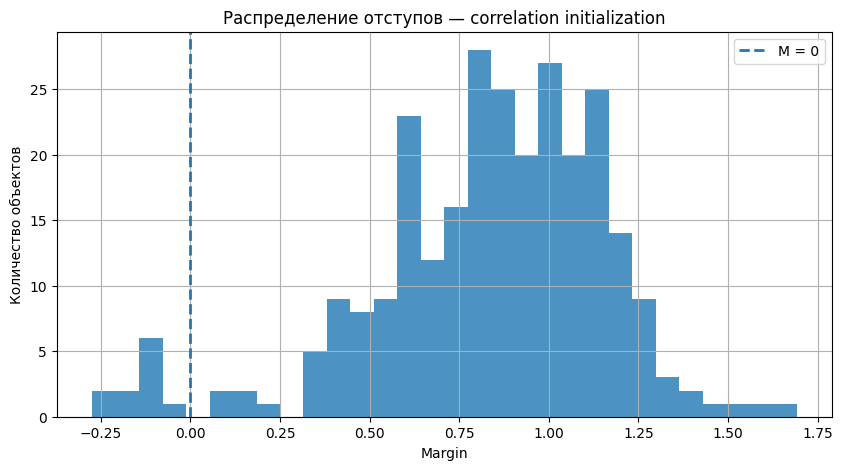

In [315]:
plt.figure(figsize=(10, 5))

plt.hist(
    correlation_margins,
    bins=30,
    alpha=0.8,
)

# Граница правильной / неправильной классификации
plt.axvline(
    x=0,
    linestyle="--",
    linewidth=2,
    label="M = 0",
)

plt.xlabel("Margin")
plt.ylabel("Количество объектов")
plt.title("Распределение отступов — correlation initialization")
plt.legend()
plt.grid()

plt.show()

In [316]:
print("Средний margin:", correlation_margins.mean())
print("Минимальный margin:", correlation_margins.min())
print("Максимальный margin:", correlation_margins.max())

print(
    "Количество отрицательных margin:",
    np.sum(correlation_margins < 0),
)

print(
    "Количество положительных margin:",
    np.sum(correlation_margins > 0),
)

Средний margin: 0.8315169296355742
Минимальный margin: -0.27405769555445
Максимальный margin: 1.6918172112287109
Количество отрицательных margin: 11
Количество положительных margin: 264


In [317]:
correlation_metrics = evaluate(
    correlation_model,
    X_test_scaled,
    y_test,
)

pd.DataFrame(
    [correlation_metrics],
    index=["Correlation init"],
)


/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:89: RuntimeWarning: divide by zero encountered in matmul
  return X @ self.w + self.b
/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:89: RuntimeWarning: overflow encountered in matmul
  return X @ self.w + self.b
/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:89: RuntimeWarning: invalid value encountered in matmul
  return X @ self.w + self.b


,accuracy,precision,recall,f1
Correlation init,0.96,0.923664,0.991803,0.956522


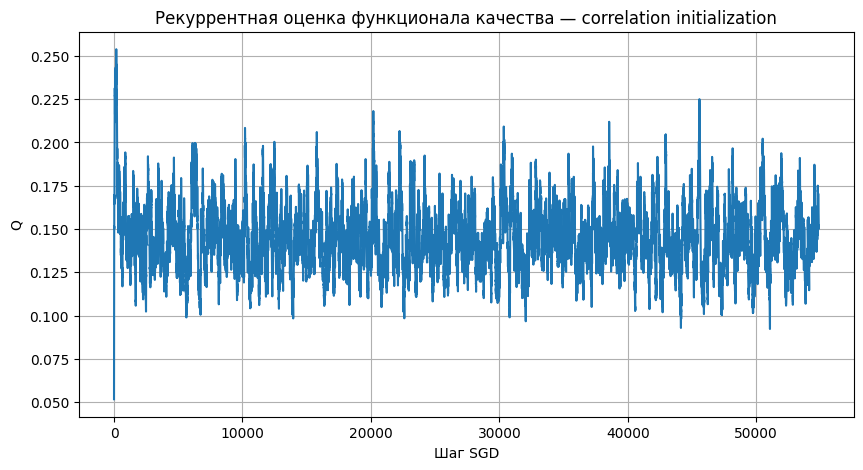

In [318]:
plt.figure(figsize=(10, 5))

plt.plot(
    correlation_model.quality_history,
)

plt.xlabel("Шаг SGD")
plt.ylabel("Q")
plt.title(
    "Рекуррентная оценка функционала качества — "
    "correlation initialization"
)

plt.grid()
plt.show()

In [319]:
correlation_predictions = correlation_model.predict(
    X_test_scaled
)

correlation_cm = confusion_matrix(
    y_test,
    correlation_predictions,
)

/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:89: RuntimeWarning: divide by zero encountered in matmul
  return X @ self.w + self.b
/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:89: RuntimeWarning: overflow encountered in matmul
  return X @ self.w + self.b
/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:89: RuntimeWarning: invalid value encountered in matmul
  return X @ self.w + self.b


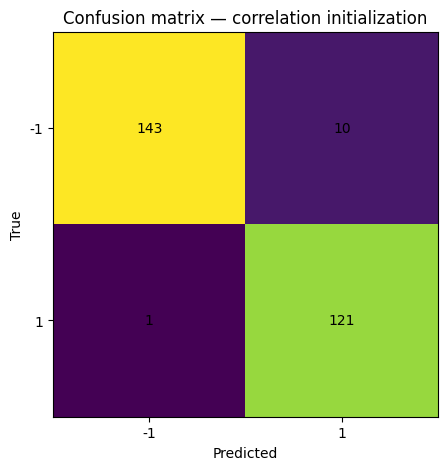

In [320]:
plt.figure(figsize=(6, 5))

plt.imshow(correlation_cm)

plt.xticks(
    [0, 1],
    [-1, 1],
)

plt.yticks(
    [0, 1],
    [-1, 1],
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(
    "Confusion matrix — correlation initialization"
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            correlation_cm[i, j],
            ha="center",
            va="center",
        )

plt.show()

## 3. Обучение с помощью  случайной инициализации весов + multistart.

In [321]:
multistart_results = []

best_multistart_model = None
best_train_loss = np.inf

for seed in range(10):

    current_model = LinearClassifier(
        learning_rate=0.001,
        beta=0.9,
        l2=0.001,
        alpha=0.01,
        epochs=50,
        random_state=seed,
        optimizer="momentum",
        init_method="random",
        sample_order="random",
    )

    current_model.fit(
        X_train_scaled,
        y_train,
    )

    train_loss = current_model.mean_loss(
        X_train_scaled,
        y_train,
        regularized=True,
    )

    multistart_results.append({
        "seed": seed,
        "train_loss": train_loss,
    })

    if train_loss < best_train_loss:
        best_train_loss = train_loss
        best_multistart_model = current_model

/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:89: RuntimeWarning: divide by zero encountered in matmul
  return X @ self.w + self.b
/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:89: RuntimeWarning: overflow encountered in matmul
  return X @ self.w + self.b
/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:89: RuntimeWarning: invalid value encountered in matmul
  return X @ self.w + self.b


In [322]:
multistart_df = pd.DataFrame(multistart_results)

multistart_df

,seed,train_loss
0,0,0.140722
1,1,0.139607
2,2,0.152369
3,3,0.143345
4,4,0.142710
5,5,0.158609
6,6,0.136668
7,7,0.138360
8,8,0.138556
9,9,0.139020


In [323]:
print("Best train loss:", best_train_loss)
print("Weights:", best_multistart_model.w)
print("Bias:", best_multistart_model.b)

Best train loss: 0.13666805035516125
Weights: [-0.82432497 -0.89895815 -0.85479912 -0.00213316]
Bias: -0.09849137256828798


In [324]:
multistart_margins = best_multistart_model.margin(
    X_test_scaled,
    y_test,
)

/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:89: RuntimeWarning: divide by zero encountered in matmul
  return X @ self.w + self.b
/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:89: RuntimeWarning: overflow encountered in matmul
  return X @ self.w + self.b
/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:89: RuntimeWarning: invalid value encountered in matmul
  return X @ self.w + self.b


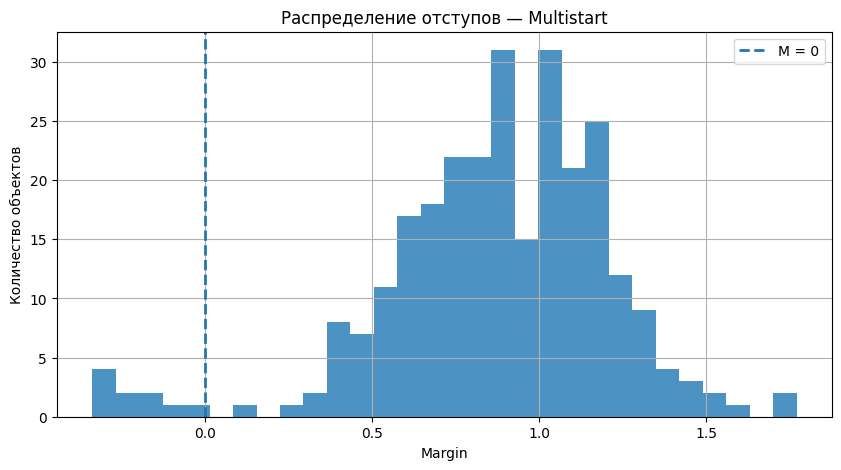

In [325]:
plt.figure(figsize=(10, 5))

plt.hist(
    multistart_margins,
    bins=30,
    alpha=0.8,
)

plt.axvline(
    x=0,
    linestyle="--",
    linewidth=2,
    label="M = 0",
)

plt.xlabel("Margin")
plt.ylabel("Количество объектов")
plt.title("Распределение отступов — Multistart")

plt.legend()
plt.grid()

plt.show()

In [326]:
print("Средний margin:", multistart_margins.mean())
print("Минимальный margin:", multistart_margins.min())
print("Максимальный margin:", multistart_margins.max())

print(
    "Ошибки:",
    np.sum(multistart_margins < 0),
)

Средний margin: 0.872985960962948
Минимальный margin: -0.337188537555014
Максимальный margin: 1.7700269880734987
Ошибки: 9


In [327]:
multistart_metrics = evaluate(
    best_multistart_model,
    X_test_scaled,
    y_test,
)

pd.DataFrame(
    [multistart_metrics],
    index=["Multistart"],
)

/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:89: RuntimeWarning: divide by zero encountered in matmul
  return X @ self.w + self.b
/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:89: RuntimeWarning: overflow encountered in matmul
  return X @ self.w + self.b
/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:89: RuntimeWarning: invalid value encountered in matmul
  return X @ self.w + self.b


,accuracy,precision,recall,f1
Multistart,0.967273,0.931298,1.0,0.964427


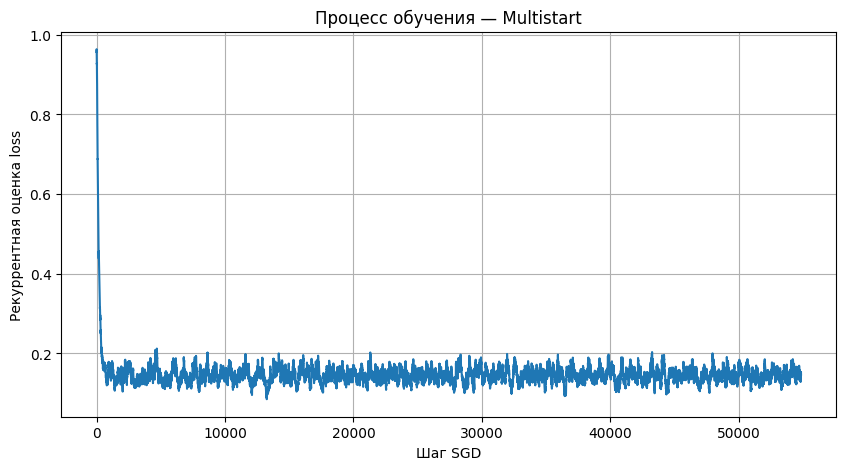

In [328]:
plt.figure(figsize=(10, 5))

plt.plot(
    best_multistart_model.quality_history
)

plt.xlabel("Шаг SGD")
plt.ylabel("Рекуррентная оценка loss")
plt.title(
    "Процесс обучения — Multistart"
)

plt.grid()
plt.show()

/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:89: RuntimeWarning: divide by zero encountered in matmul
  return X @ self.w + self.b
/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:89: RuntimeWarning: overflow encountered in matmul
  return X @ self.w + self.b
/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:89: RuntimeWarning: invalid value encountered in matmul
  return X @ self.w + self.b


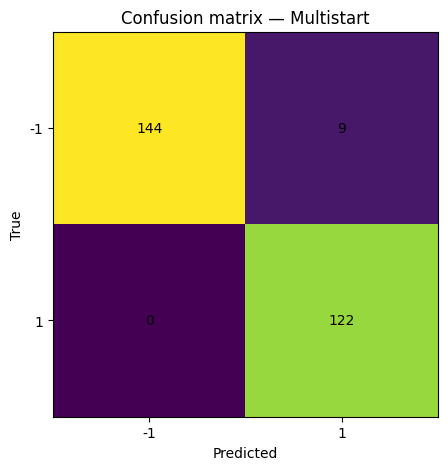

In [329]:
multistart_predictions = best_multistart_model.predict(
    X_test_scaled
)

multistart_cm = confusion_matrix(
    y_test,
    multistart_predictions,
)

plt.figure(figsize=(6, 5))

plt.imshow(multistart_cm)

plt.xticks([0, 1], [-1, 1])
plt.yticks([0, 1], [-1, 1])

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion matrix — Multistart")

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            multistart_cm[i, j],
            ha="center",
            va="center",
        )

plt.show()

## 4. Обучение с рандомным способом предъявления и с предъявлением по отступам

In [330]:
random_order_model = LinearClassifier(
    learning_rate=0.001,
    beta=0.9,
    l2=0.001,
    alpha=0.01,
    epochs=50,
    random_state=42,
    optimizer="momentum",
    init_method="random",
    sample_order="random",
)

random_order_model.fit(
    X_train_scaled,
    y_train,
)

/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:89: RuntimeWarning: divide by zero encountered in matmul
  return X @ self.w + self.b
/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:89: RuntimeWarning: overflow encountered in matmul
  return X @ self.w + self.b
/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:89: RuntimeWarning: invalid value encountered in matmul
  return X @ self.w + self.b


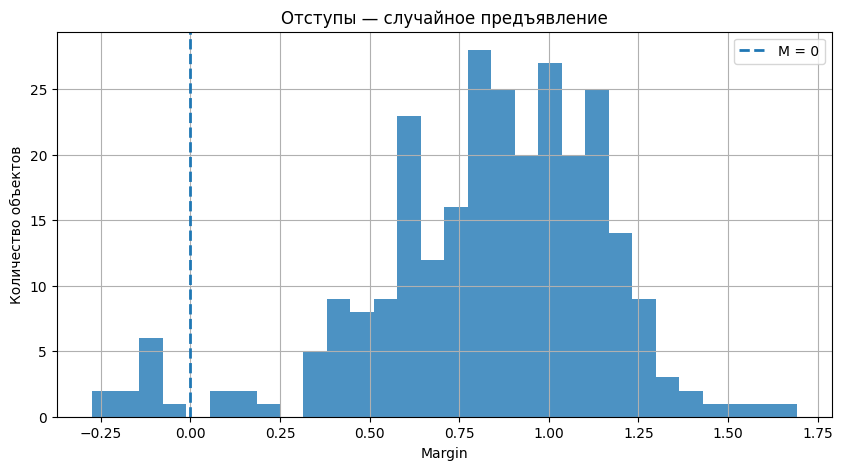

In [331]:
random_margins = random_order_model.margin(
    X_test_scaled,
    y_test,
)

plt.figure(figsize=(10, 5))

plt.hist(
    random_margins,
    bins=30,
    alpha=0.8,
)

plt.axvline(
    x=0,
    linestyle="--",
    linewidth=2,
    label="M = 0",
)

plt.xlabel("Margin")
plt.ylabel("Количество объектов")
plt.title("Отступы — случайное предъявление")

plt.legend()
plt.grid()
plt.show()

In [332]:
print("Средний margin:", random_margins.mean())
print("Минимальный margin:", random_margins.min())
print("Максимальный margin:", random_margins.max())
print("Ошибок:", np.sum(random_margins < 0))

Средний margin: 0.8315169296355742
Минимальный margin: -0.27405769555445
Максимальный margin: 1.6918172112287109
Ошибок: 11


### Объявление модели с предъявлением по модулю отступа

In [333]:
margin_order_model = LinearClassifier(
    learning_rate=0.001,
    beta=0.9,
    l2=0.001,
    alpha=0.01,
    epochs=50,
    random_state=42,
    optimizer="momentum",
    init_method="random",
    sample_order="margin",
)

margin_order_model.fit(
    X_train_scaled,
    y_train,
)

/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:89: RuntimeWarning: divide by zero encountered in matmul
  return X @ self.w + self.b
/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:89: RuntimeWarning: overflow encountered in matmul
  return X @ self.w + self.b
/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:89: RuntimeWarning: invalid value encountered in matmul
  return X @ self.w + self.b


/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:89: RuntimeWarning: divide by zero encountered in matmul
  return X @ self.w + self.b
/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:89: RuntimeWarning: overflow encountered in matmul
  return X @ self.w + self.b
/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:89: RuntimeWarning: invalid value encountered in matmul
  return X @ self.w + self.b


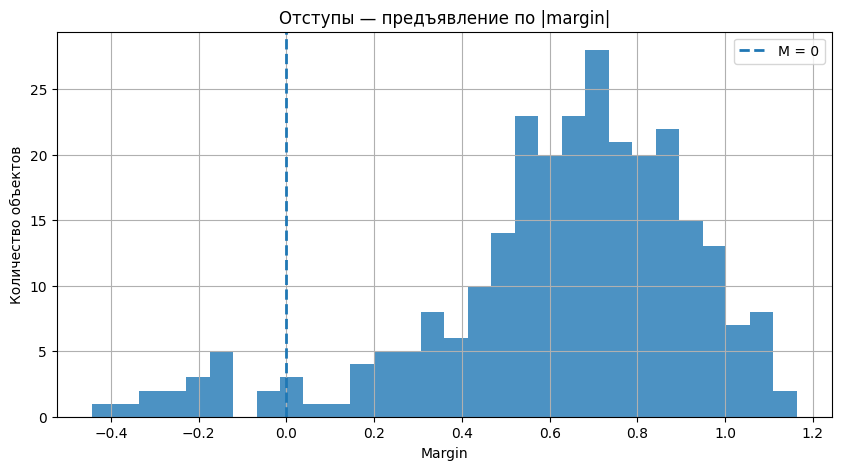

In [334]:
margin_margins = margin_order_model.margin(
    X_test_scaled,
    y_test,
)

plt.figure(figsize=(10, 5))

plt.hist(
    margin_margins,
    bins=30,
    alpha=0.8,
)

plt.axvline(
    x=0,
    linestyle="--",
    linewidth=2,
    label="M = 0",
)

plt.xlabel("Margin")
plt.ylabel("Количество объектов")
plt.title("Отступы — предъявление по |margin|")

plt.legend()
plt.grid()
plt.show()

In [335]:
print("Средний margin:", margin_margins.mean())
print("Минимальный margin:", margin_margins.min())
print("Максимальный margin:", margin_margins.max())
print("Ошибок:", np.sum(margin_margins < 0))

Средний margin: 0.624822769951676
Минимальный margin: -0.4429169093286053
Максимальный margin: 1.1631542100257155
Ошибок: 17


### Метрики моделей 


In [336]:
random_metrics = evaluate(
    random_order_model,
    X_test_scaled,
    y_test,
)

margin_metrics = evaluate(
    margin_order_model,
    X_test_scaled,
    y_test,
)

comparison_order = pd.DataFrame([
    {
        "model": "Random order",
        **random_metrics,
    },
    {
        "model": "Margin order",
        **margin_metrics,
    },
])

comparison_order

/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:89: RuntimeWarning: divide by zero encountered in matmul
  return X @ self.w + self.b
/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:89: RuntimeWarning: overflow encountered in matmul
  return X @ self.w + self.b
/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:89: RuntimeWarning: invalid value encountered in matmul
  return X @ self.w + self.b
/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:89: RuntimeWarning: divide by zero encountered in matmul
  return X @ self.w + self.b
/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:89: RuntimeWarning: overflow encountered in matmul
  return X @ self.w + self.b
/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:89: RuntimeWarning: invalid value encountered in matmul
  return X @ self.w + self.b


,model,accuracy,precision,recall,f1
0,Random order,0.960000,0.923664,0.991803,0.956522
1,Margin order,0.938182,0.920000,0.942623,0.931174


### Cравнение процесса обучения 

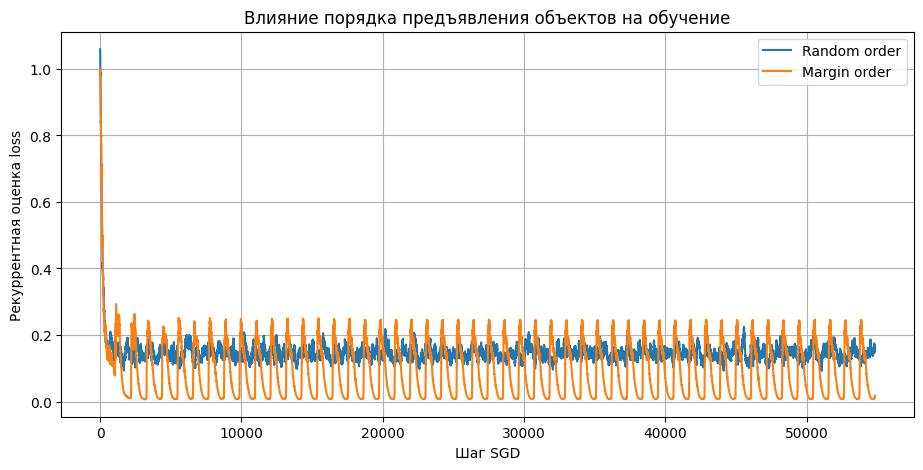

In [337]:
plt.figure(figsize=(11, 5))

plt.plot(
    random_order_model.quality_history,
    label="Random order",
)

plt.plot(
    margin_order_model.quality_history,
    label="Margin order",
)

plt.xlabel("Шаг SGD")
plt.ylabel("Рекуррентная оценка loss")
plt.title("Влияние порядка предъявления объектов на обучение")

plt.legend()
plt.grid()
plt.show()

### Матрица ошибок — random

/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:89: RuntimeWarning: divide by zero encountered in matmul
  return X @ self.w + self.b
/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:89: RuntimeWarning: overflow encountered in matmul
  return X @ self.w + self.b
/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:89: RuntimeWarning: invalid value encountered in matmul
  return X @ self.w + self.b


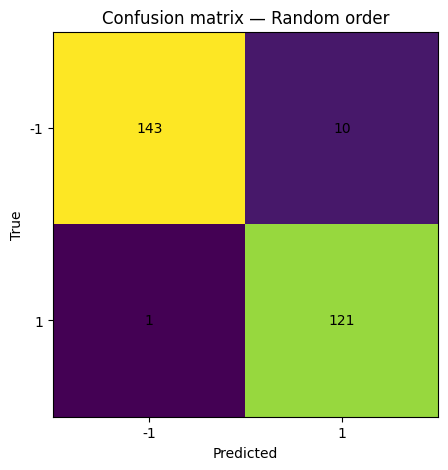

In [338]:
random_predictions = random_order_model.predict(
    X_test_scaled
)

random_cm = confusion_matrix(
    y_test,
    random_predictions,
)

plt.figure(figsize=(6, 5))

plt.imshow(random_cm)

plt.xticks([0, 1], [-1, 1])
plt.yticks([0, 1], [-1, 1])

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion matrix — Random order")

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            random_cm[i, j],
            ha="center",
            va="center",
        )

plt.show()

### Матрица ошибок — margin

/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:89: RuntimeWarning: divide by zero encountered in matmul
  return X @ self.w + self.b
/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:89: RuntimeWarning: overflow encountered in matmul
  return X @ self.w + self.b
/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:89: RuntimeWarning: invalid value encountered in matmul
  return X @ self.w + self.b


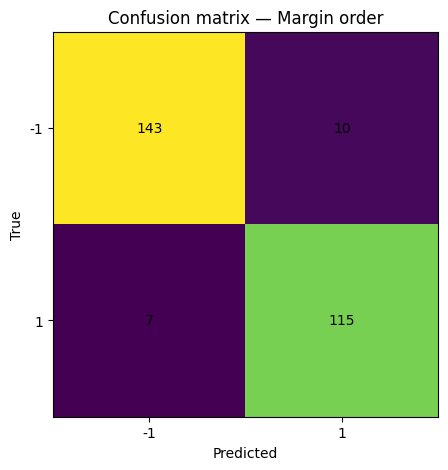

In [339]:
margin_predictions = margin_order_model.predict(
    X_test_scaled
)

margin_cm = confusion_matrix(
    y_test,
    margin_predictions,
)

plt.figure(figsize=(6, 5))

plt.imshow(margin_cm)

plt.xticks([0, 1], [-1, 1])
plt.yticks([0, 1], [-1, 1])

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion matrix — Margin order")

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            margin_cm[i, j],
            ha="center",
            va="center",
        )

plt.show()

## 5. Скорейший градиентный спуск

In [340]:
steepest_model = LinearClassifier(
    l2=0.001,
    alpha=0.1,
    epochs=100,
    random_state=42,
    optimizer="steepest",
    init_method="random",
)

steepest_model.fit(
    X_train_scaled,
    y_train,
)

/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:89: RuntimeWarning: divide by zero encountered in matmul
  return X @ self.w + self.b
/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:89: RuntimeWarning: overflow encountered in matmul
  return X @ self.w + self.b
/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:89: RuntimeWarning: invalid value encountered in matmul
  return X @ self.w + self.b
/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:257: RuntimeWarning: divide by zero encountered in matmul
  projection = X @ grad_w + grad_b
/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:257: RuntimeWarning: overflow encountered in matmul
  projection = X @ grad_w + grad_b
/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:257: RuntimeWarning: invalid value encountered in matmul
  projection = X @ grad_w + grad_b


In [341]:
print("Weights:", steepest_model.w)
print("Bias:", steepest_model.b)

Weights: [-0.81088562 -0.91905498 -0.8808644   0.00221157]
Bias: -0.11030082041932623


/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:89: RuntimeWarning: divide by zero encountered in matmul
  return X @ self.w + self.b
/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:89: RuntimeWarning: overflow encountered in matmul
  return X @ self.w + self.b
/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:89: RuntimeWarning: invalid value encountered in matmul
  return X @ self.w + self.b


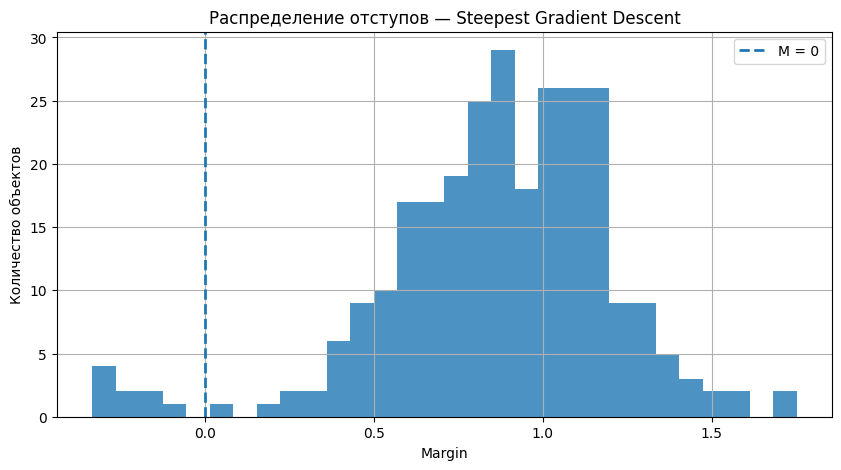

In [342]:
steepest_margins = steepest_model.margin(
    X_test_scaled,
    y_test,
)
plt.figure(figsize=(10, 5))

plt.hist(
    steepest_margins,
    bins=30,
    alpha=0.8,
)

plt.axvline(
    x=0,
    linestyle="--",
    linewidth=2,
    label="M = 0",
)

plt.xlabel("Margin")
plt.ylabel("Количество объектов")
plt.title("Распределение отступов — Steepest Gradient Descent")

plt.legend()
plt.grid()
plt.show()

In [343]:
print("Средний margin:", steepest_margins.mean())
print("Минимальный margin:", steepest_margins.min())
print("Максимальный margin:", steepest_margins.max())

print(
    "Количество ошибок:",
    np.sum(steepest_margins < 0),
)

Средний margin: 0.8686208552810152
Минимальный margin: -0.3335404039959916
Максимальный margin: 1.7515151066064638
Количество ошибок: 9


In [344]:
steepest_metrics = evaluate(
    steepest_model,
    X_test_scaled,
    y_test,
)

pd.DataFrame(
    [steepest_metrics],
    index=["Steepest"],
)

/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:89: RuntimeWarning: divide by zero encountered in matmul
  return X @ self.w + self.b
/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:89: RuntimeWarning: overflow encountered in matmul
  return X @ self.w + self.b
/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:89: RuntimeWarning: invalid value encountered in matmul
  return X @ self.w + self.b


,accuracy,precision,recall,f1
Steepest,0.967273,0.931298,1.0,0.964427


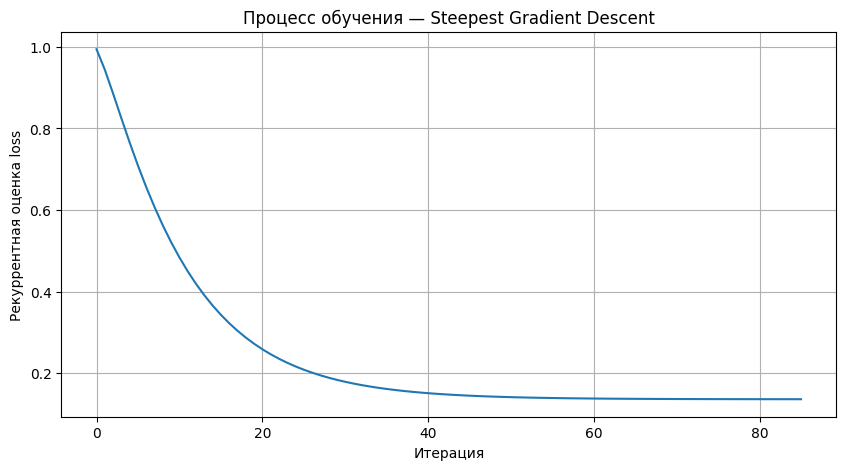

In [345]:
plt.figure(figsize=(10, 5))

plt.plot(
    steepest_model.quality_history
)

plt.xlabel("Итерация")
plt.ylabel("Рекуррентная оценка loss")
plt.title("Процесс обучения — Steepest Gradient Descent")

plt.grid()
plt.show()

In [346]:
steepest_predictions = steepest_model.predict(
    X_test_scaled
)

steepest_cm = confusion_matrix(
    y_test,
    steepest_predictions,
)

/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:89: RuntimeWarning: divide by zero encountered in matmul
  return X @ self.w + self.b
/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:89: RuntimeWarning: overflow encountered in matmul
  return X @ self.w + self.b
/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:89: RuntimeWarning: invalid value encountered in matmul
  return X @ self.w + self.b


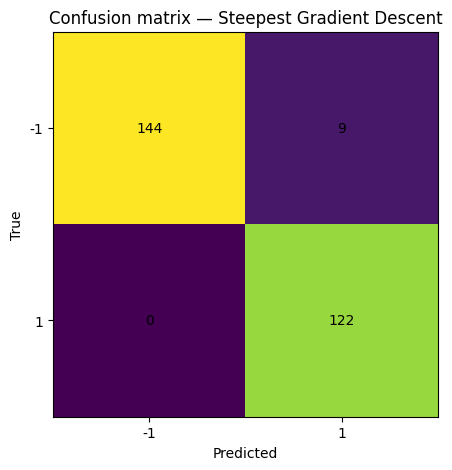

In [347]:
plt.figure(figsize=(6, 5))

plt.imshow(steepest_cm)

plt.xticks([0, 1], [-1, 1])
plt.yticks([0, 1], [-1, 1])

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion matrix — Steepest Gradient Descent")

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            steepest_cm[i, j],
            ha="center",
            va="center",
        )

plt.show()

## 6. Сравнение моделей

In [348]:
models = {
    "Correlation init": correlation_model,
    "Multistart": best_multistart_model,
    "Random order": random_order_model,
    "Margin order": margin_order_model,
    "Steepest": steepest_model,
}

In [349]:
results = []

for name, model in models.items():
    metrics = evaluate(
        model,
        X_test_scaled,
        y_test,
    )

    test_loss = model.mean_loss(
        X_test_scaled,
        y_test,
        regularized=False,
    )

    results.append({
        "model": name,
        "accuracy": metrics["accuracy"],
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "f1": metrics["f1"],
        "test_loss": test_loss,
    })

results_df = pd.DataFrame(results)

results_df

/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:89: RuntimeWarning: divide by zero encountered in matmul
  return X @ self.w + self.b
/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:89: RuntimeWarning: overflow encountered in matmul
  return X @ self.w + self.b
/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:89: RuntimeWarning: invalid value encountered in matmul
  return X @ self.w + self.b
/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:89: RuntimeWarning: divide by zero encountered in matmul
  return X @ self.w + self.b
/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:89: RuntimeWarning: overflow encountered in matmul
  return X @ self.w + self.b
/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:89: RuntimeWarning: invalid value encountered in matmul
  return X @ self.w + self.b
/var/folders/pj/k38hq2ps3_zc0f

,model,accuracy,precision,recall,f1,test_loss
0,Correlation init,0.960000,0.923664,0.991803,0.956522,0.140219
1,Multistart,0.967273,0.931298,1.000000,0.964427,0.134267
2,Random order,0.960000,0.923664,0.991803,0.956522,0.140219
3,Margin order,0.938182,0.920000,0.942623,0.931174,0.235412
4,Steepest,0.967273,0.931298,1.000000,0.964427,0.133200


In [350]:
results_df.sort_values(
    by="f1",
    ascending=False,
)

,model,accuracy,precision,recall,f1,test_loss
1,Multistart,0.967273,0.931298,1.000000,0.964427,0.134267
4,Steepest,0.967273,0.931298,1.000000,0.964427,0.133200
0,Correlation init,0.960000,0.923664,0.991803,0.956522,0.140219
2,Random order,0.960000,0.923664,0.991803,0.956522,0.140219
3,Margin order,0.938182,0.920000,0.942623,0.931174,0.235412


In [351]:
best_row = results_df.loc[
    results_df["f1"].idxmax()
]

best_row

model        Multistart
accuracy       0.967273
precision      0.931298
recall              1.0
f1             0.964427
test_loss      0.134267
Name: 1, dtype: object

In [352]:
best_model_name = best_row["model"]

best_model = models[
    best_model_name
]

print("Лучшая модель:", best_model_name)

Лучшая модель: Multistart


## Сравнение с эталонным RidgeClassifier

In [353]:
from sklearn.linear_model import RidgeClassifier

In [354]:
reference_model = RidgeClassifier(
    alpha=0.001,
)

reference_model.fit(
    X_train_scaled,
    y_train,
)

reference_predictions = reference_model.predict(
    X_test_scaled
)

/Users/mishgan/Desktop/учеба/fall-2026/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/mishgan/Desktop/учеба/fall-2026/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/mishgan/Desktop/учеба/fall-2026/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [355]:
ridge_metrics = {
    "accuracy": accuracy_score(
        y_test,
        reference_predictions,
    ),
    "precision": precision_score(
        y_test,
        reference_predictions,
        pos_label=1,
    ),
    "recall": recall_score(
        y_test,
        reference_predictions,
        pos_label=1,
    ),
    "f1": f1_score(
        y_test,
        reference_predictions,
        pos_label=1,
    ),
}

ridge_metrics

{'accuracy': 0.9672727272727273,
 'precision': 0.9312977099236641,
 'recall': 1.0,
 'f1': 0.9644268774703557}

In [356]:
best_metrics = evaluate(
    best_model,
    X_test_scaled,
    y_test,
)

comparison = pd.DataFrame([
    {
        "model": f"Our: {best_model_name}",
        **best_metrics,
    },
    {
        "model": "RidgeClassifier",
        **ridge_metrics,
    },
])

comparison

/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:89: RuntimeWarning: divide by zero encountered in matmul
  return X @ self.w + self.b
/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:89: RuntimeWarning: overflow encountered in matmul
  return X @ self.w + self.b
/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:89: RuntimeWarning: invalid value encountered in matmul
  return X @ self.w + self.b


,model,accuracy,precision,recall,f1
0,Our: Multistart,0.967273,0.931298,1.0,0.964427
1,RidgeClassifier,0.967273,0.931298,1.0,0.964427


In [357]:
our_predictions = best_model.predict(
    X_test_scaled
)

same_predictions = np.array_equal(
    our_predictions,
    reference_predictions,
)

print(
    "Предсказания полностью совпадают:",
    same_predictions,
)

Предсказания полностью совпадают: True


/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:89: RuntimeWarning: divide by zero encountered in matmul
  return X @ self.w + self.b
/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:89: RuntimeWarning: overflow encountered in matmul
  return X @ self.w + self.b
/var/folders/pj/k38hq2ps3_zc0fn61d707bqm0000gn/T/ipykernel_1663/3366188761.py:89: RuntimeWarning: invalid value encountered in matmul
  return X @ self.w + self.b


In [358]:
our_cm = confusion_matrix(
    y_test,
    our_predictions,
)

print("Our model:")
print(our_cm)

Our model:
[[144   9]
 [  0 122]]


In [359]:
ridge_cm = confusion_matrix(
    y_test,
    reference_predictions,
)

print("RidgeClassifier:")
print(ridge_cm)

RidgeClassifier:
[[144   9]
 [  0 122]]
